# **Tarea 7. Usar APIs en la nube**

## **Alumna:** Isaura Yutsil Flores Escamilla

## **Matrícula:** A01796552

## **Objetivo:** El presente código tiene como objetivo consumir la API de Azure para la visión computacional (Compute vision)

--- Análisis de Imagen ---
Descripción: a painting of a person sitting at a table (Confianza: 0.75)

--- Texto detectado (OCR) ---
No se detectó texto en la imagen.


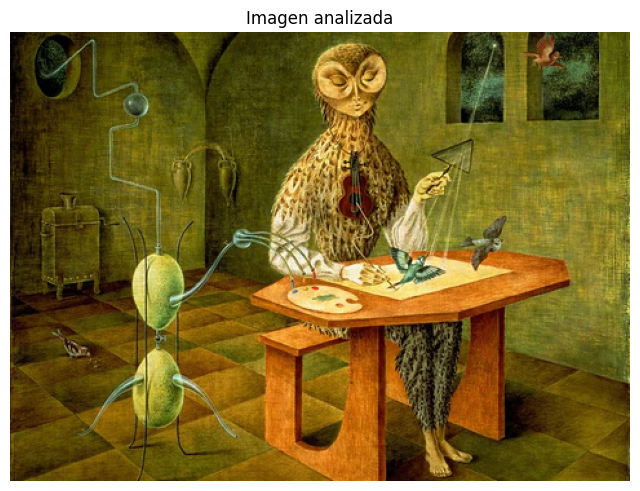

In [12]:
import os
from azure.ai.vision.imageanalysis import ImageAnalysisClient
from azure.ai.vision.imageanalysis.models import VisualFeatures
from azure.core.credentials import AzureKeyCredential

# 1. Configuración (Pega aquí tus credenciales del paso 1)
endpoint = "https://computervisionaiyut.cognitiveservices.azure.com/"
key = "3K80D0nNUMViXPzNs2BM34HIkAX68N1kd7yDbU8uEMhpPn2VchAyJQQJ99CCACYeBjFXJ3w3AAAFACOGVW2h"

# 2. Crear el cliente
client = ImageAnalysisClient(
    endpoint=endpoint,
    credential=AzureKeyCredential(key)
)

# 3. URL de la imagen (Recuerda usar el link RAW que corregimos)
image_url = "https://raw.githubusercontent.com/YutFlower/Computo_Nube/main/remedios.png"

# 4. Análisis: Pedimos descripción (Caption) y Texto (Read)
result = client.analyze_from_url(
    image_url=image_url,
    visual_features=[VisualFeatures.CAPTION, VisualFeatures.READ],
    # gender_neutral_caption=True
)

# 5. Mostrar resultados
print("--- Análisis de Imagen ---")
if result.caption:
    print(f"Descripción: {result.caption.text} (Confianza: {result.caption.confidence:.2f})")

print("\n--- Texto detectado (OCR) ---")
# Verificamos si existe el objeto, si hay bloques y si esos bloques tienen líneas
if result.read and result.read.blocks:
    for block in result.read.blocks:
        for line in block.lines:
            print(f"Línea encontrada: {line.text}")
else:
    print("No se detectó texto en la imagen.")

import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# 2. Descargar y mostrar la imagen
response = requests.get(image_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')  # Oculta los ejes para que se vea más limpia
plt.title("Imagen analizada")
plt.show()
